In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# testing with noise factor 0.3

cae_metrics_factor03 = {
    "Fold 1": {"PSNR": 28.47, "SSIM": 0.7082, "EPI": 0.0555},
    "Fold 2": {"PSNR": 28.29, "SSIM": 0.7102, "EPI": 0.0545},
    "Fold 3": {"PSNR": 30.74, "SSIM": 0.8204, "EPI": 0.2748},
    "Fold 4": {"PSNR": 20.51, "SSIM": 0.1069, "EPI": 0.0077},
    "Fold 5": {"PSNR": 28.23, "SSIM": 0.7072, "EPI": 0.0560}
}

# testing with noise factor 0.2

cae_metrics_factor02 = {
    "Fold 1": {"PSNR": 25.61, "SSIM": 0.5604, "EPI": 0.0381},
    "Fold 2": {"PSNR": 25.21, "SSIM": 0.4090, "EPI": 0.0343},
    "Fold 3": {"PSNR": 26.19, "SSIM": 0.6134, "EPI": 0.0540},
    "Fold 4": {"PSNR": 20.52, "SSIM": 0.1069, "EPI": 0.0077},
    "Fold 5": {"PSNR": 25.36, "SSIM": 0.6057, "EPI": 0.0408}
}

# testing with noise factor 0.4

cae_metrics_factor04 = {
    "Fold 1": {"PSNR": 25.17, "SSIM": 0.5292, "EPI": 0.0353},
    "Fold 2": {"PSNR": 24.86, "SSIM": 0.5283, "EPI": 0.0359},
    "Fold 3": {"PSNR": 24.70, "SSIM": 0.5179, "EPI": 0.0405},
    "Fold 4": {"PSNR": 20.50, "SSIM": 0.1070, "EPI": 0.0077},
    "Fold 5": {"PSNR": 25.85, "SSIM": 0.5576, "EPI": 0.0396}
}

In [3]:
all_data = {
    "0.2": cae_metrics_factor02,
    "0.3": cae_metrics_factor03,
    "0.4": cae_metrics_factor04,
}

metrics = ["PSNR", "SSIM", "EPI"]
folds = list(cae_metrics_factor02.keys())

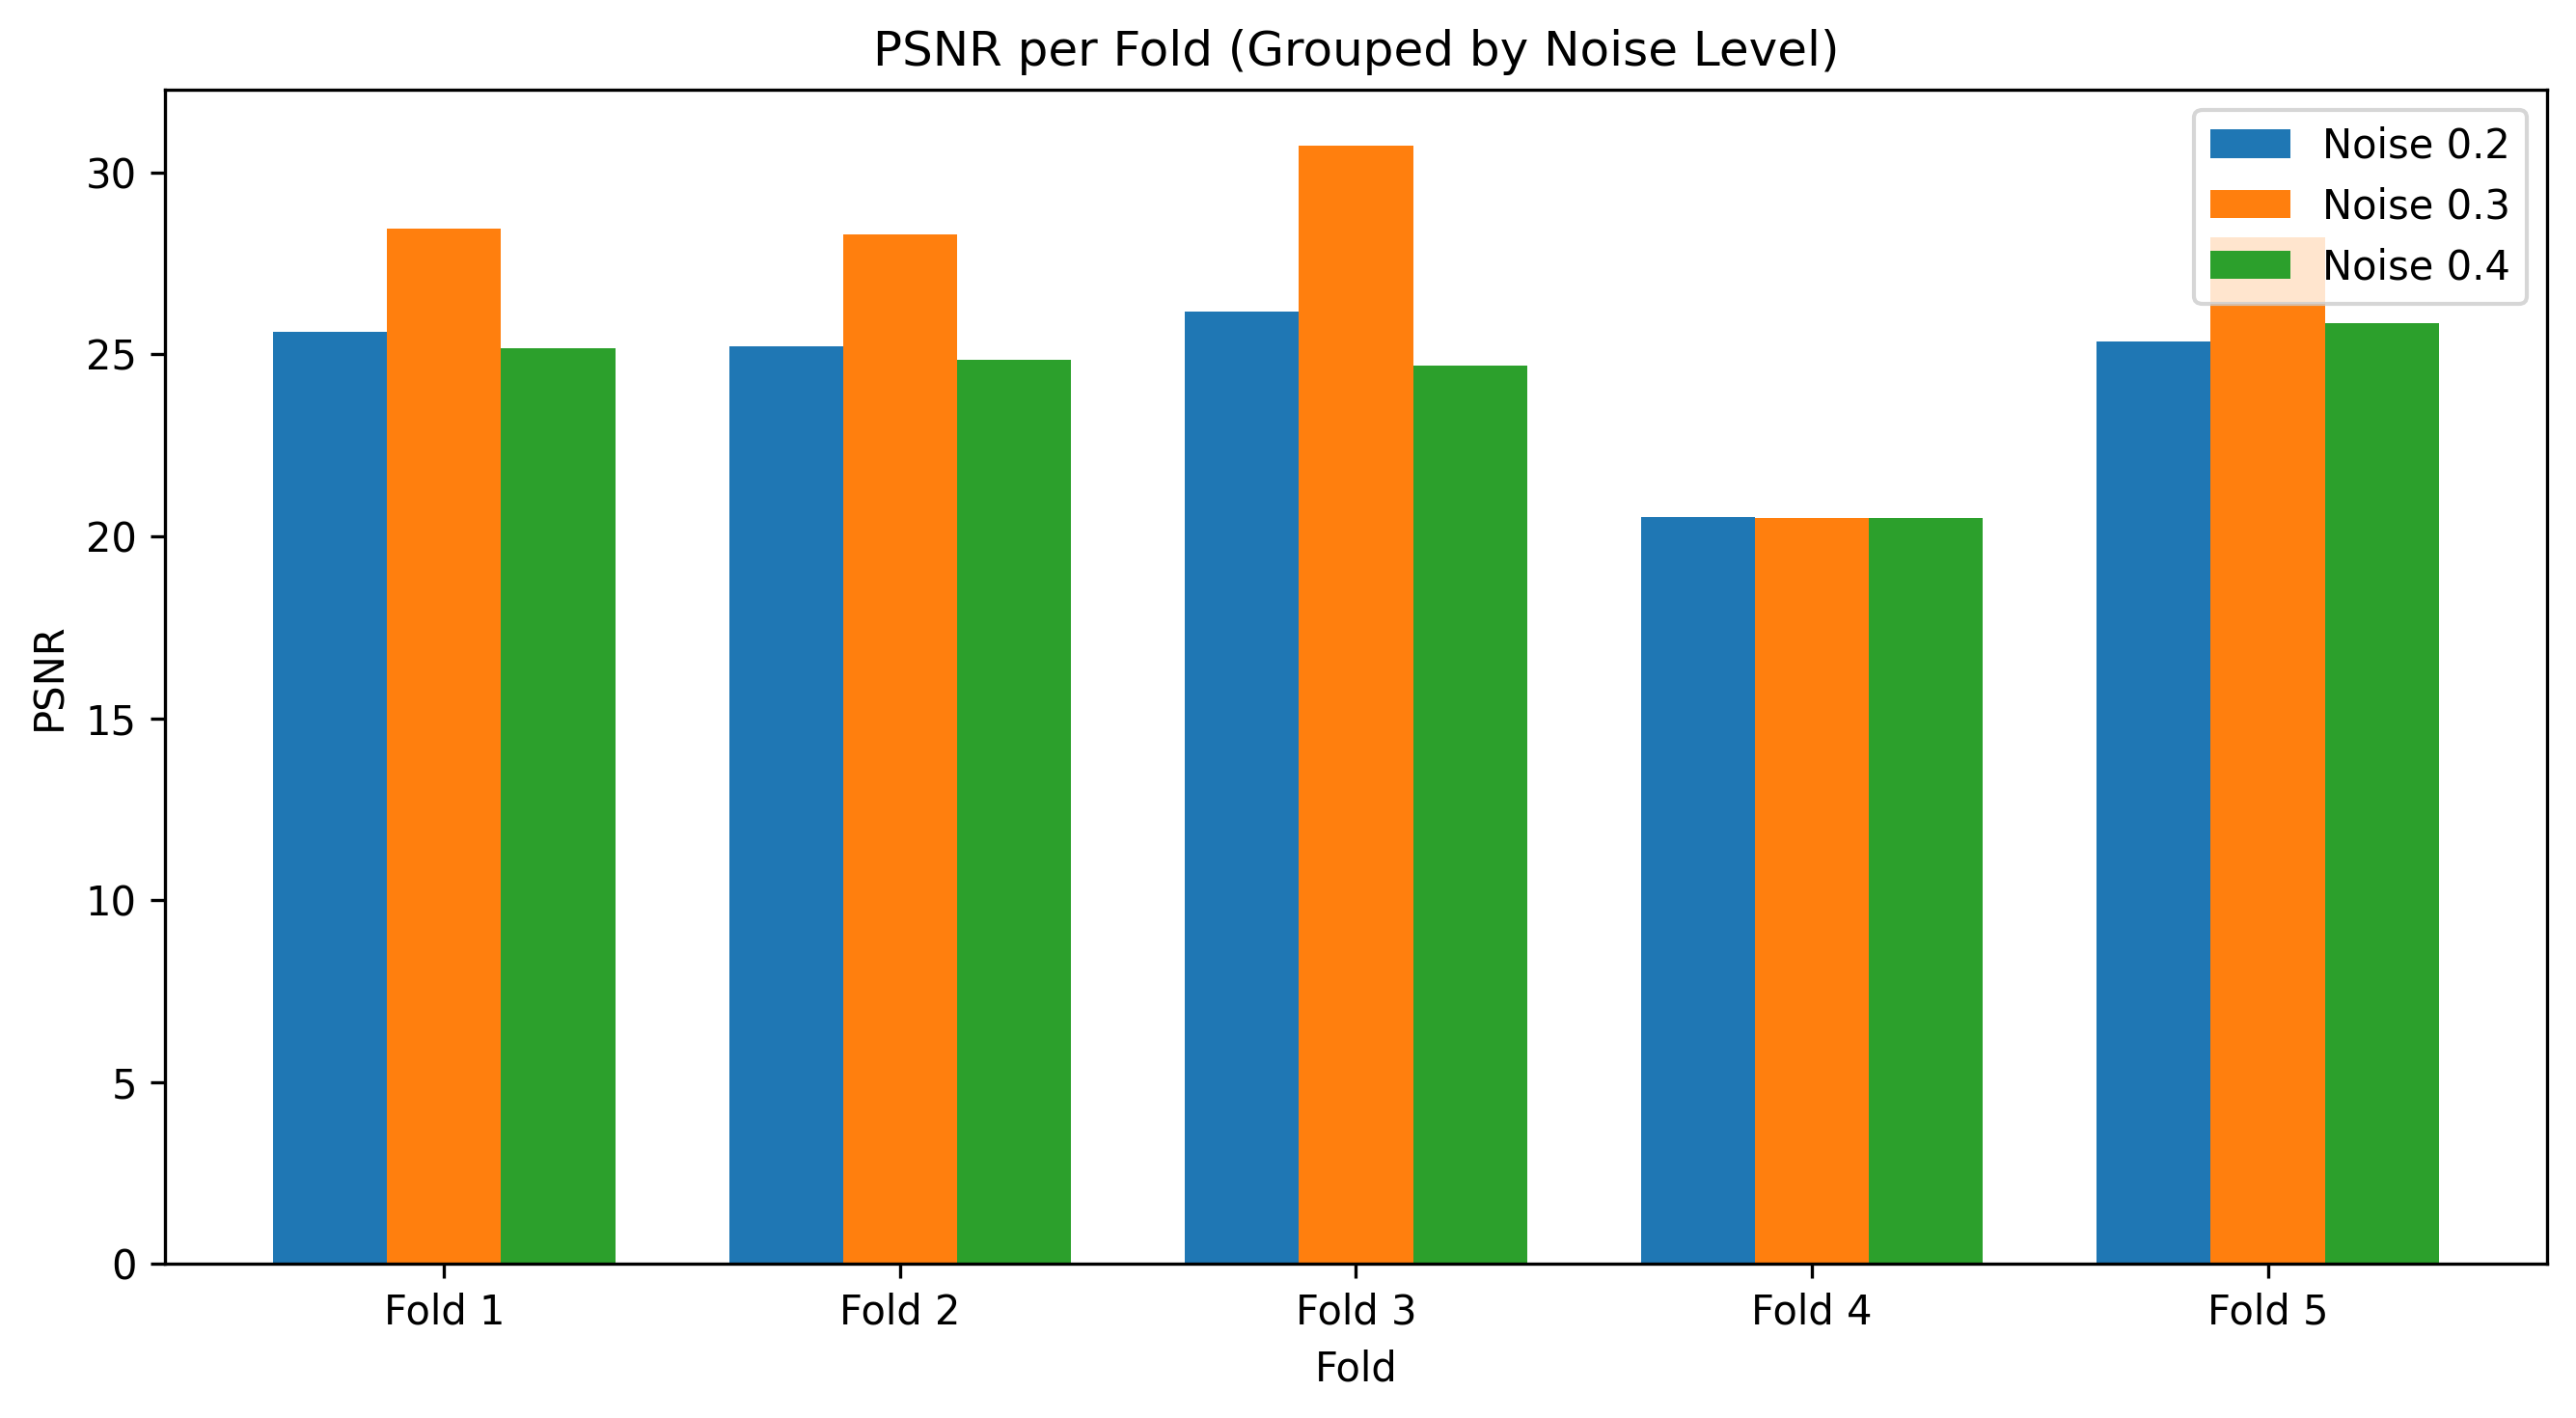

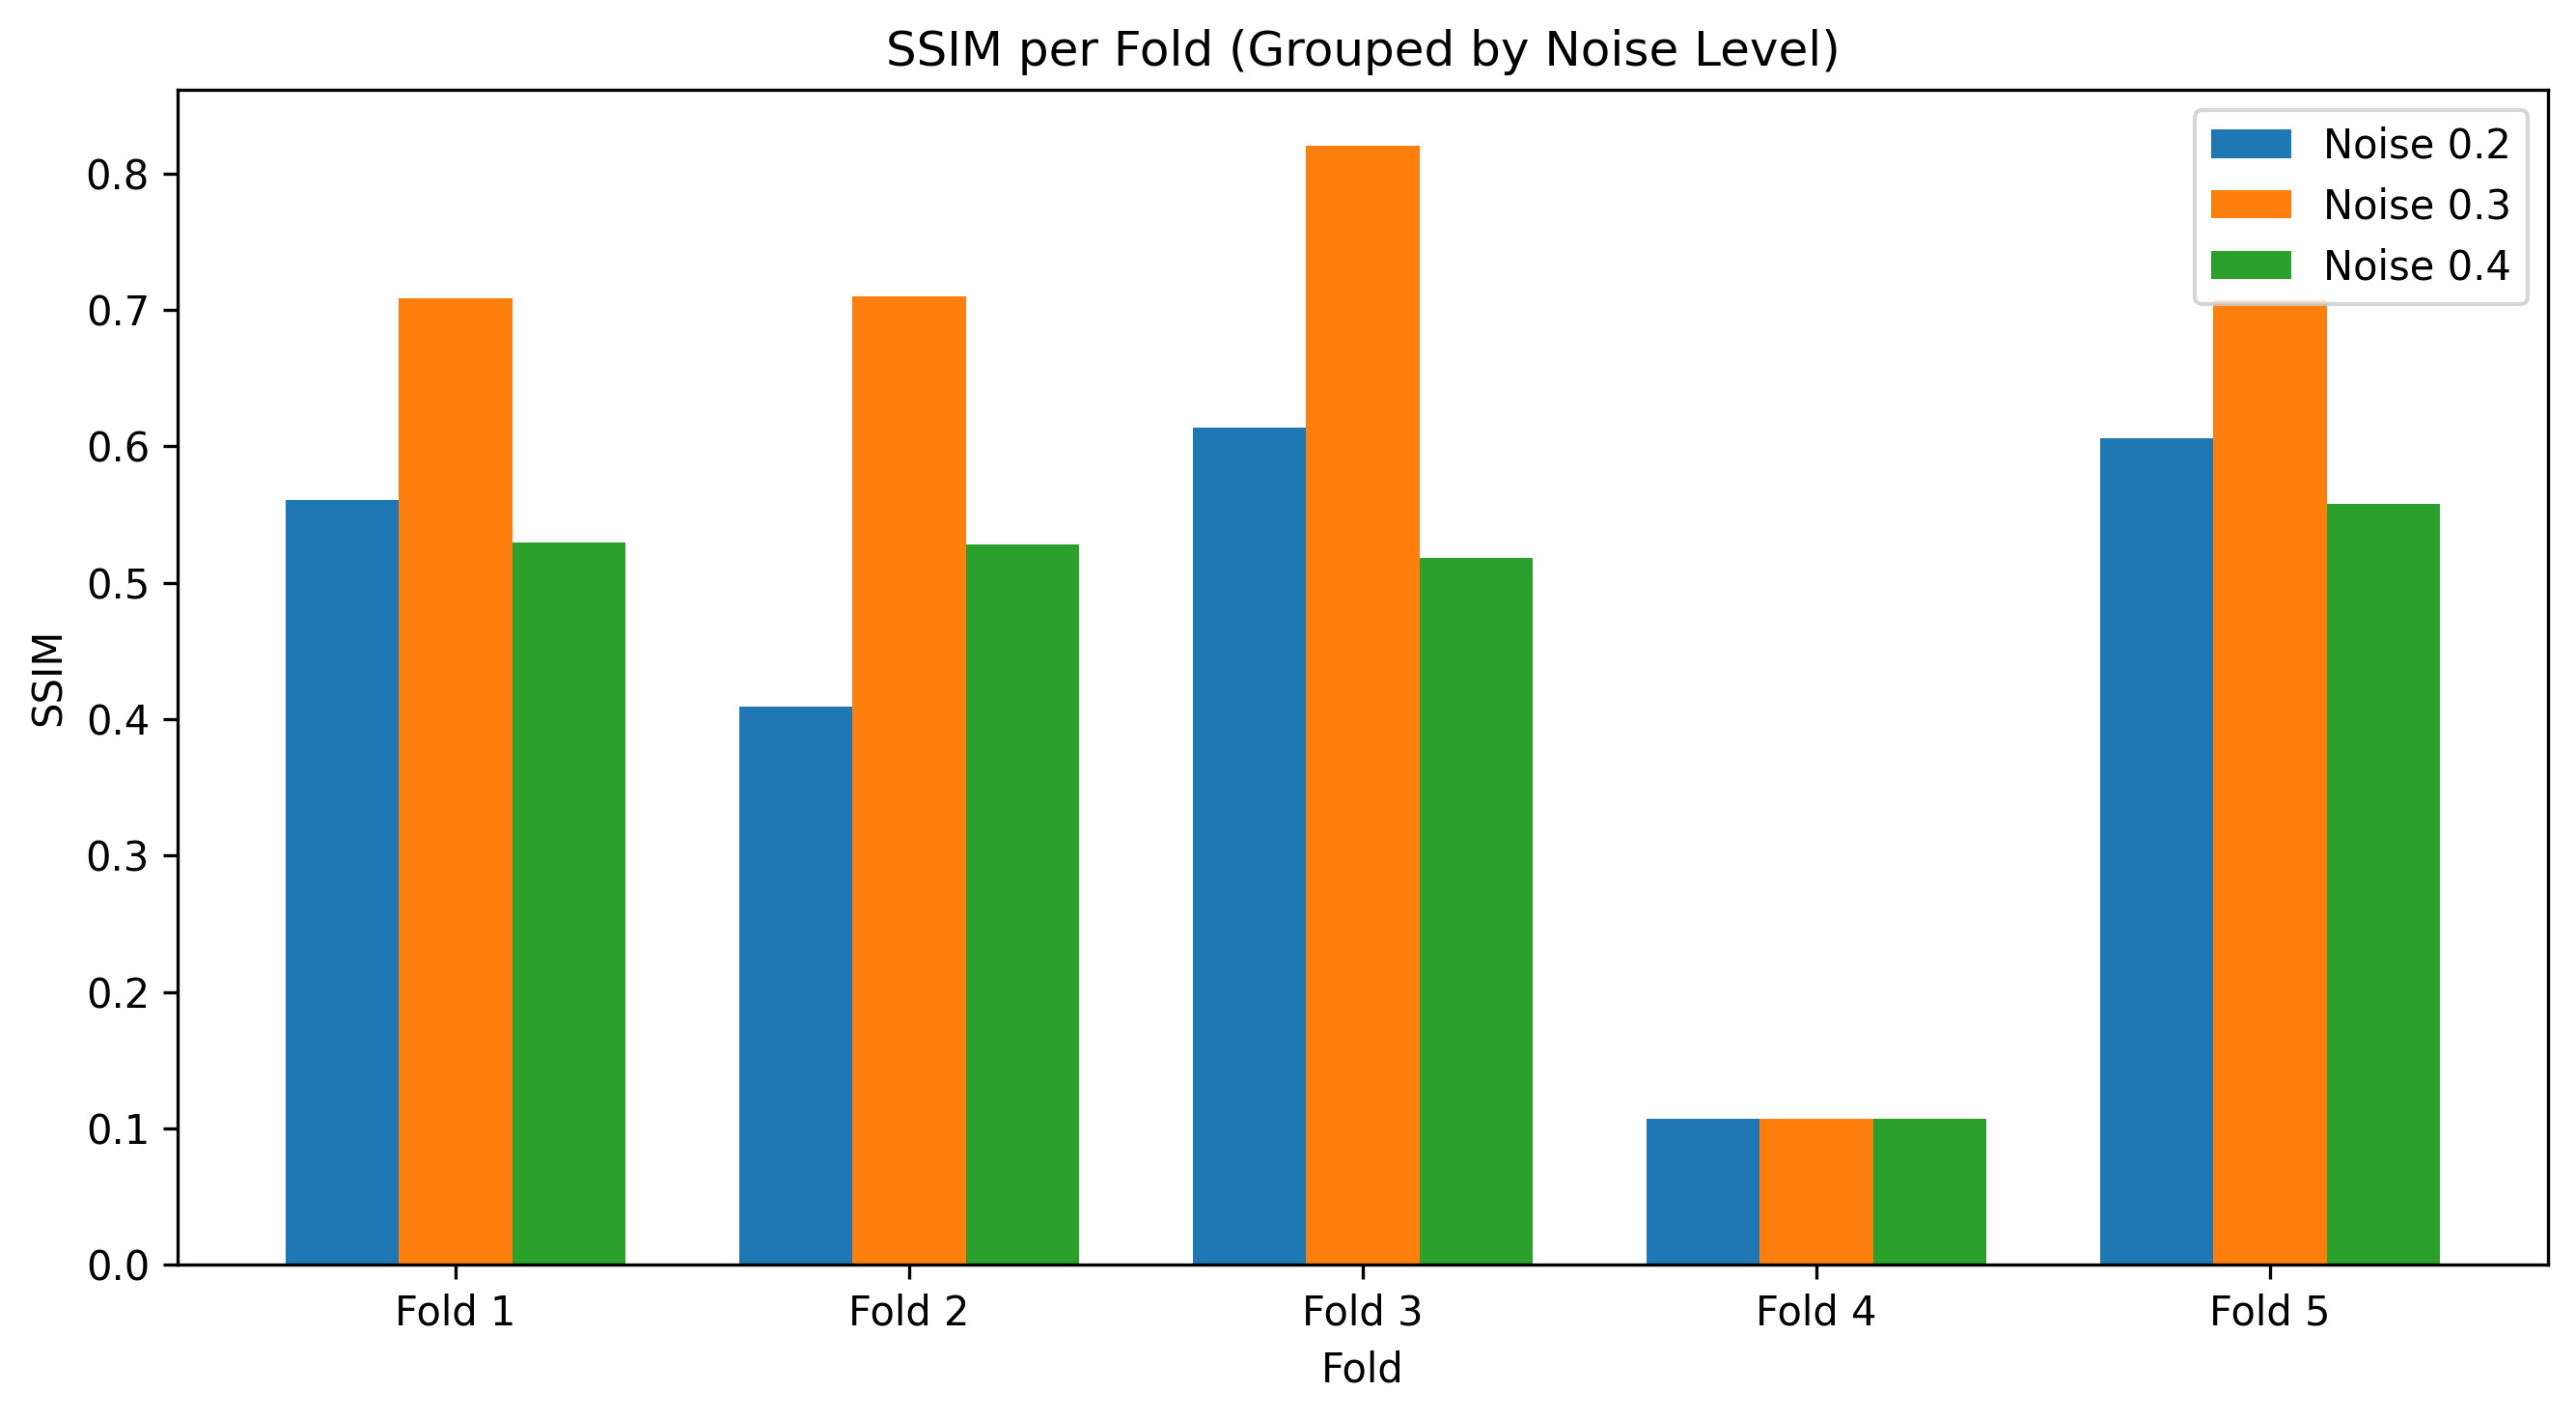

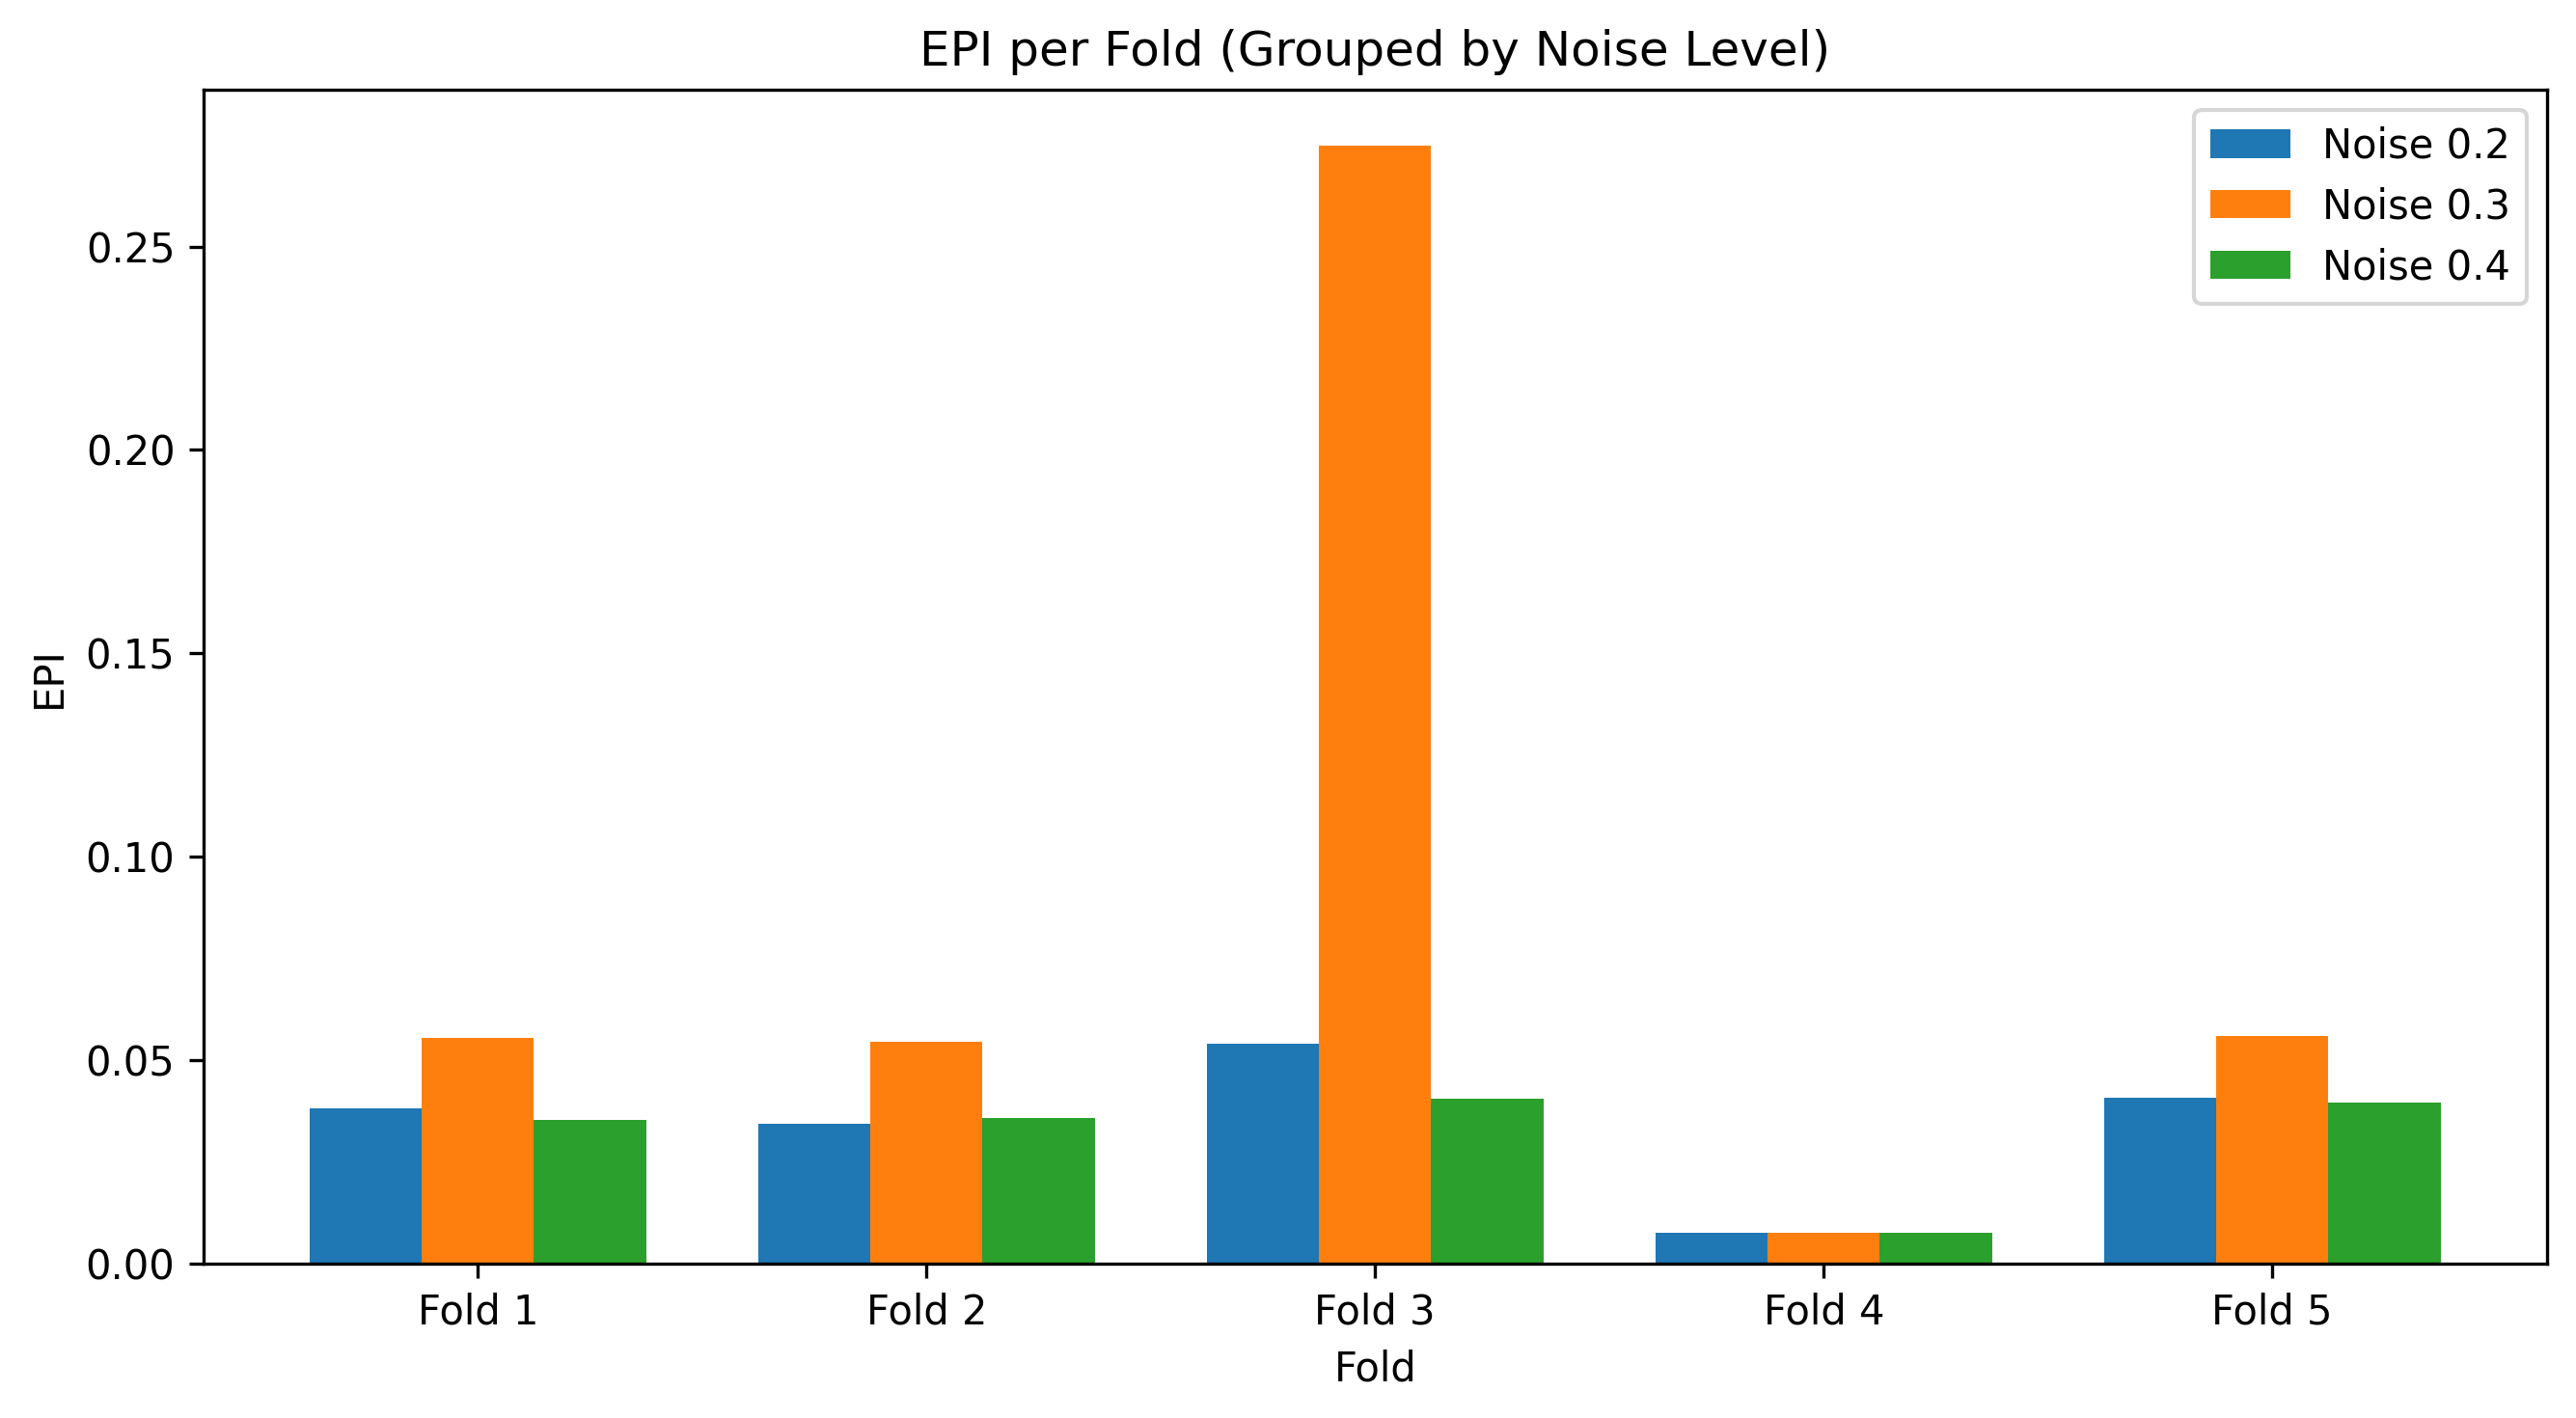

In [4]:

for metric in metrics:
    plt.figure(figsize=(9,5), dpi=300)

    x = np.arange(len(folds))
    width = 0.25
    i = 0

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        plt.bar(x + i*width, values, width=width, label=f"Noise {noise}")
        i += 1

    plt.xticks(x + width, folds)
    plt.title(f"{metric} per Fold (Grouped by Noise Level)")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

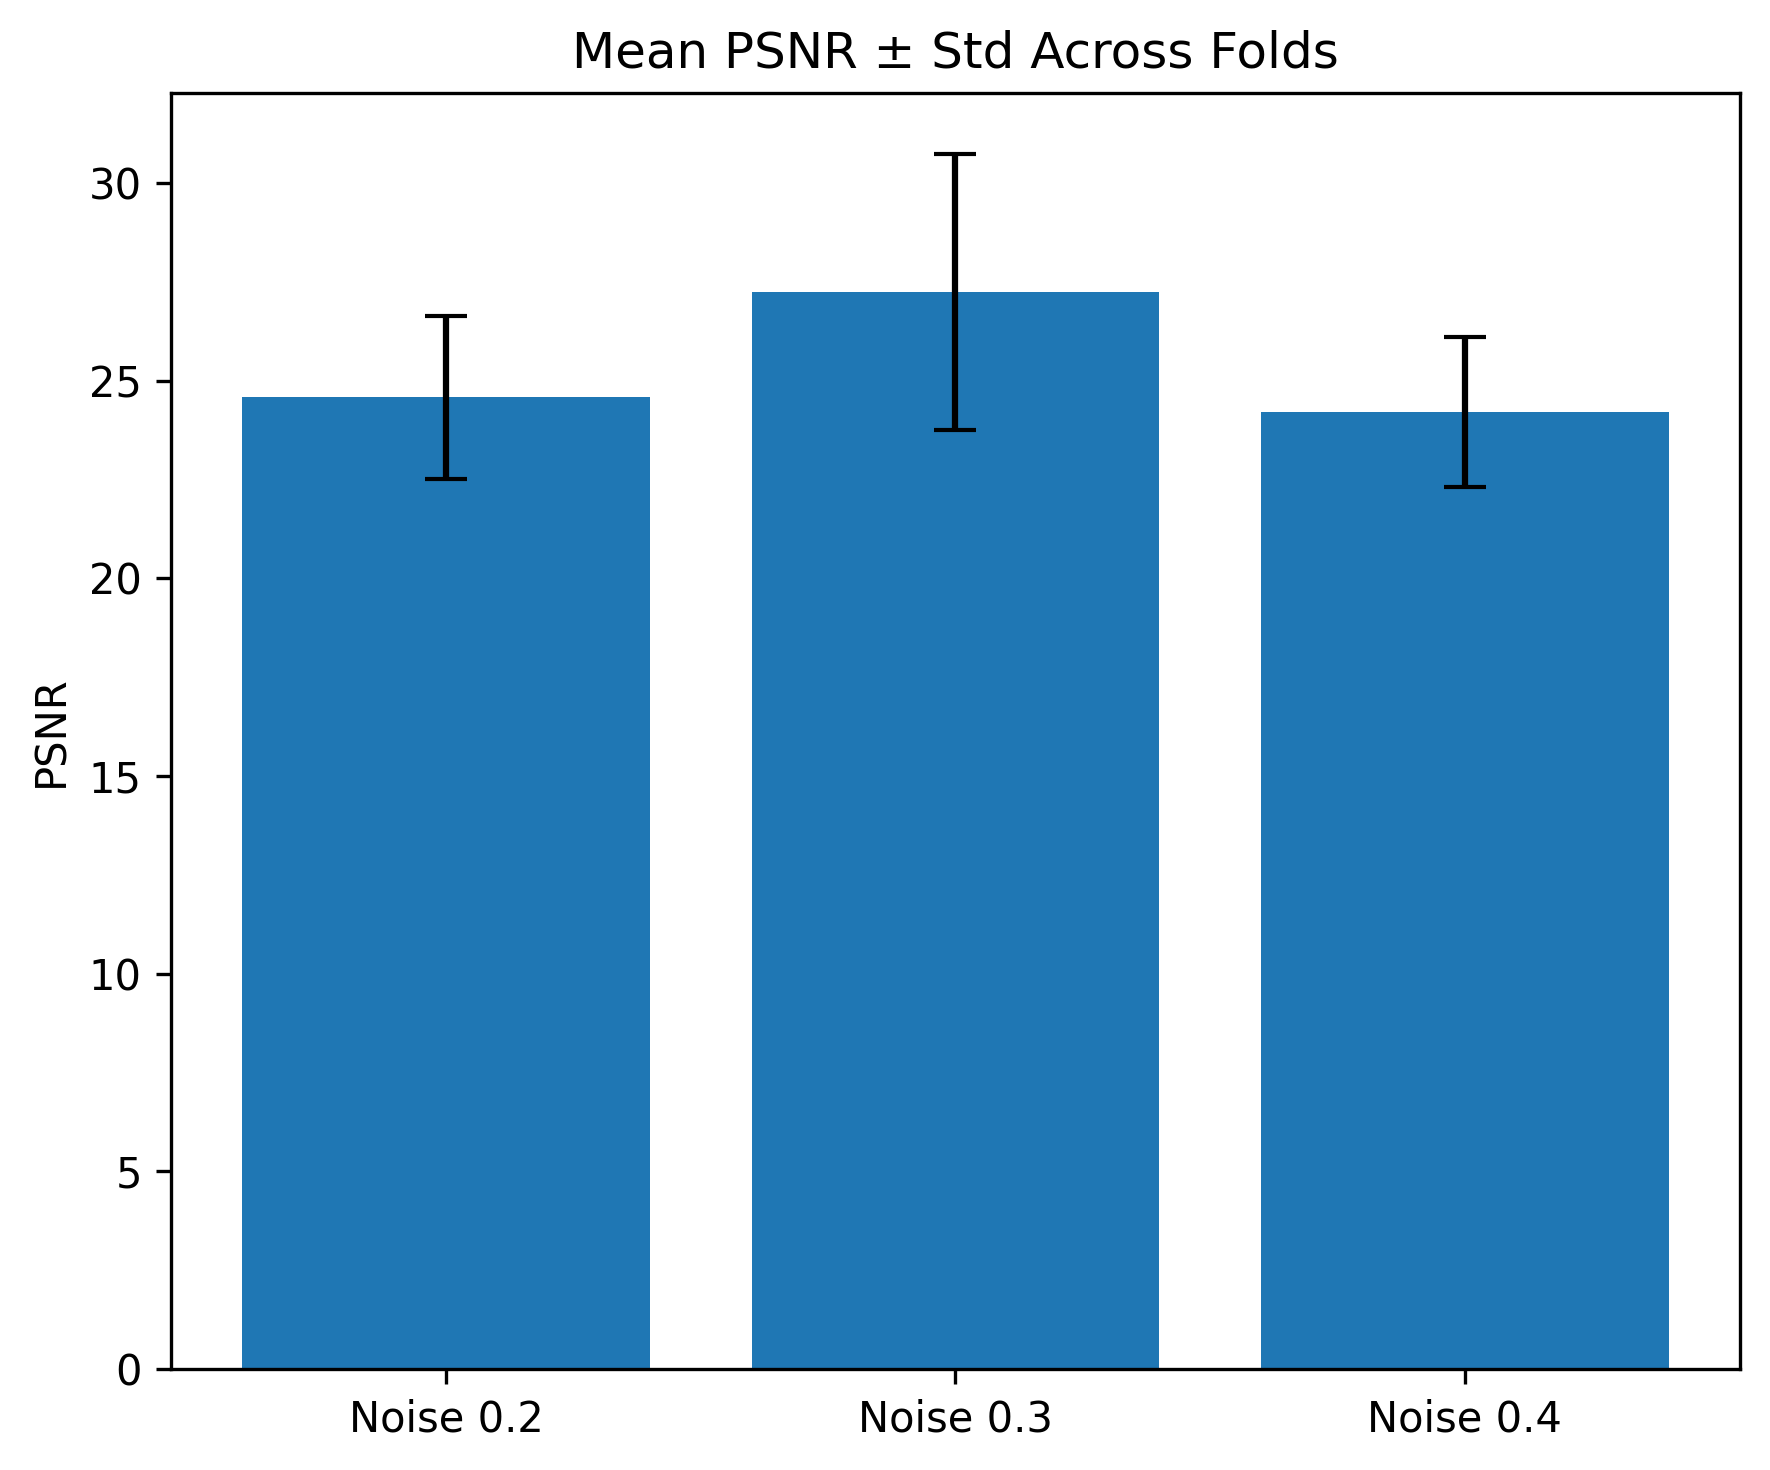

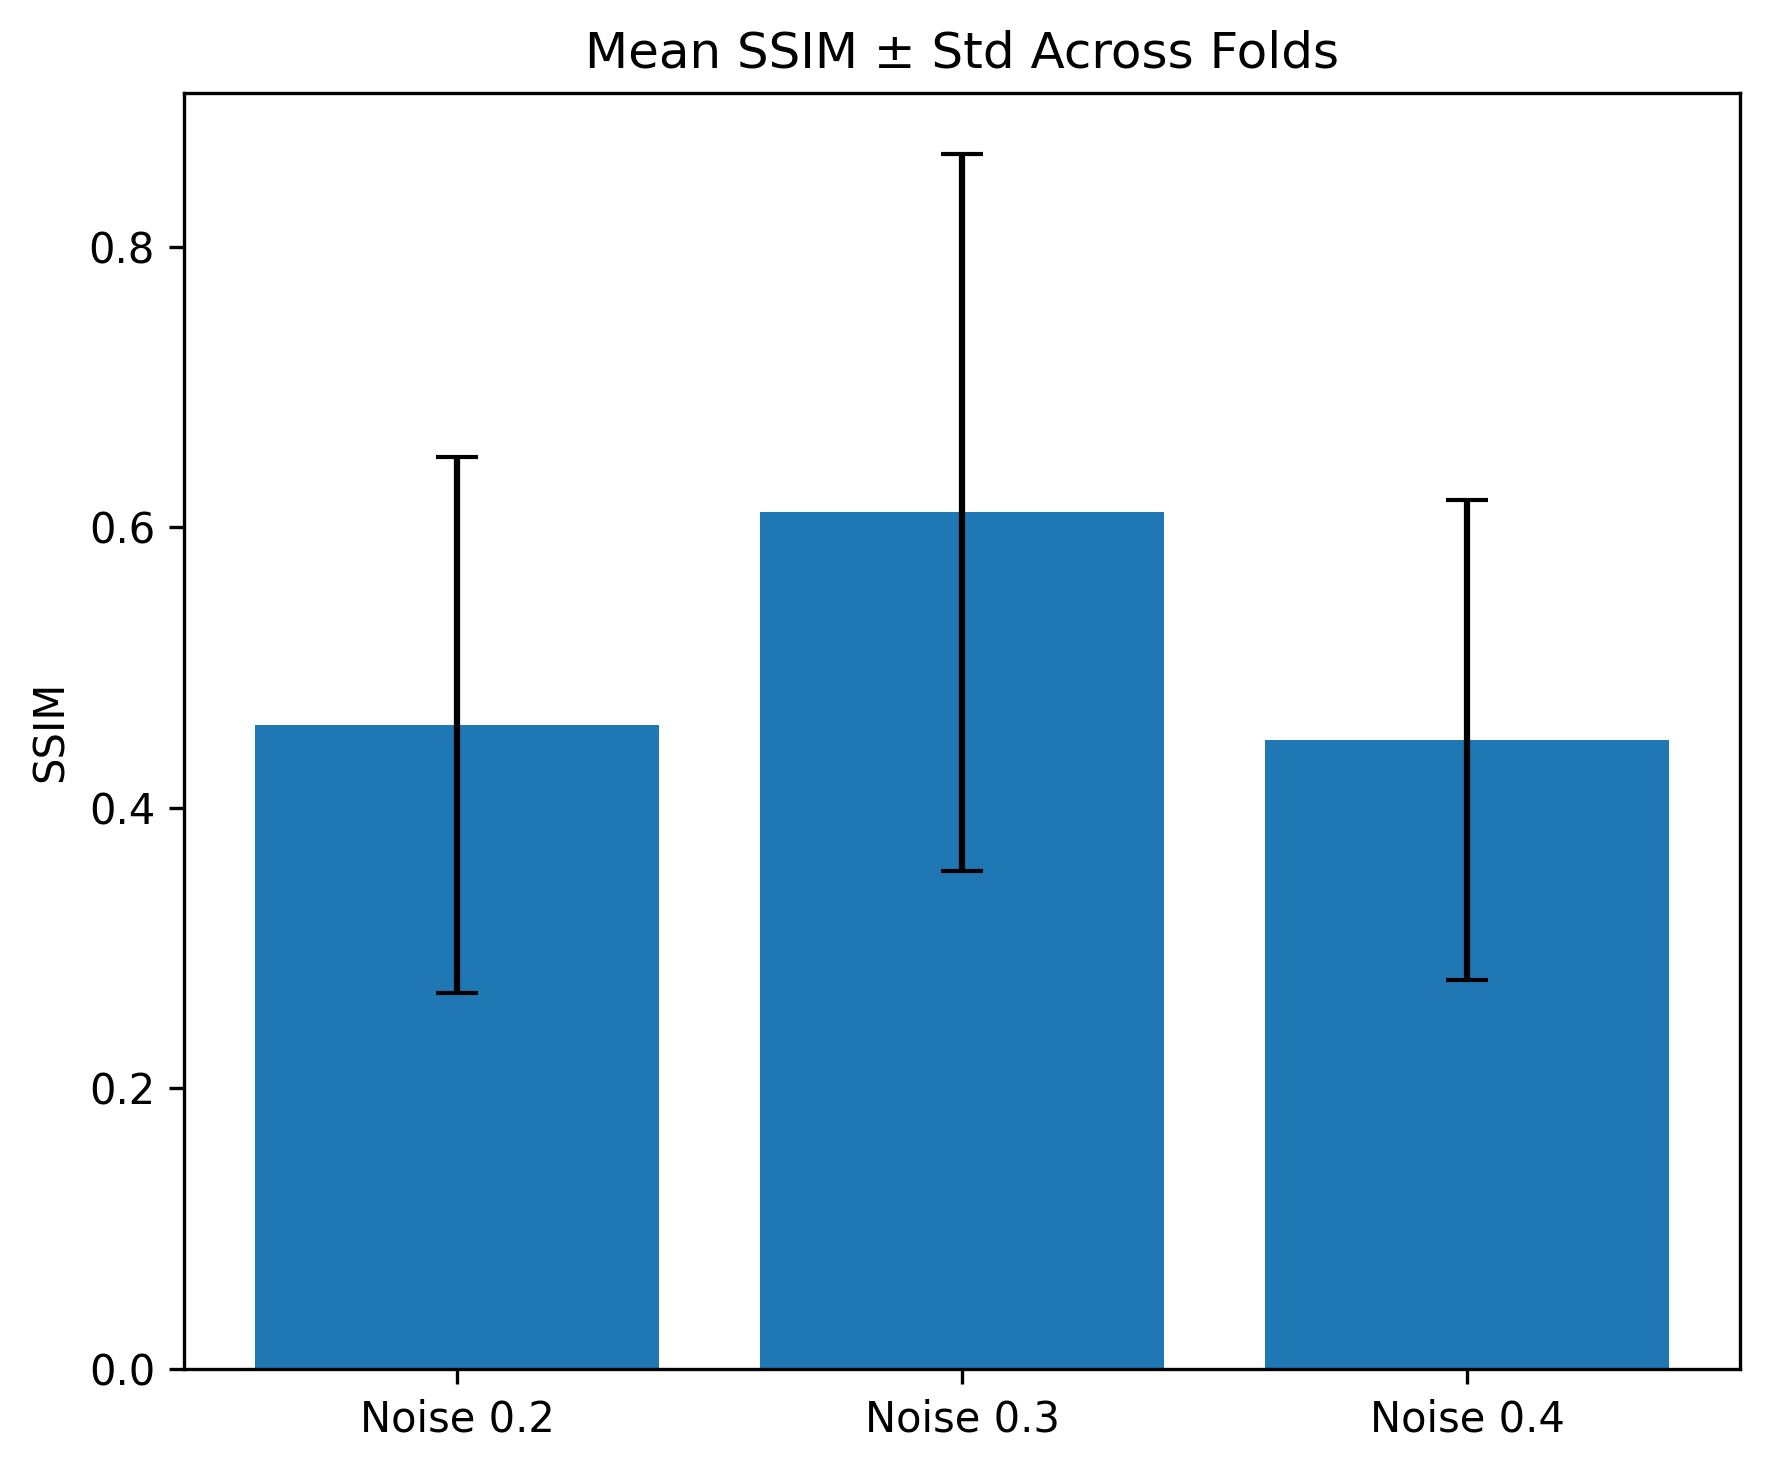

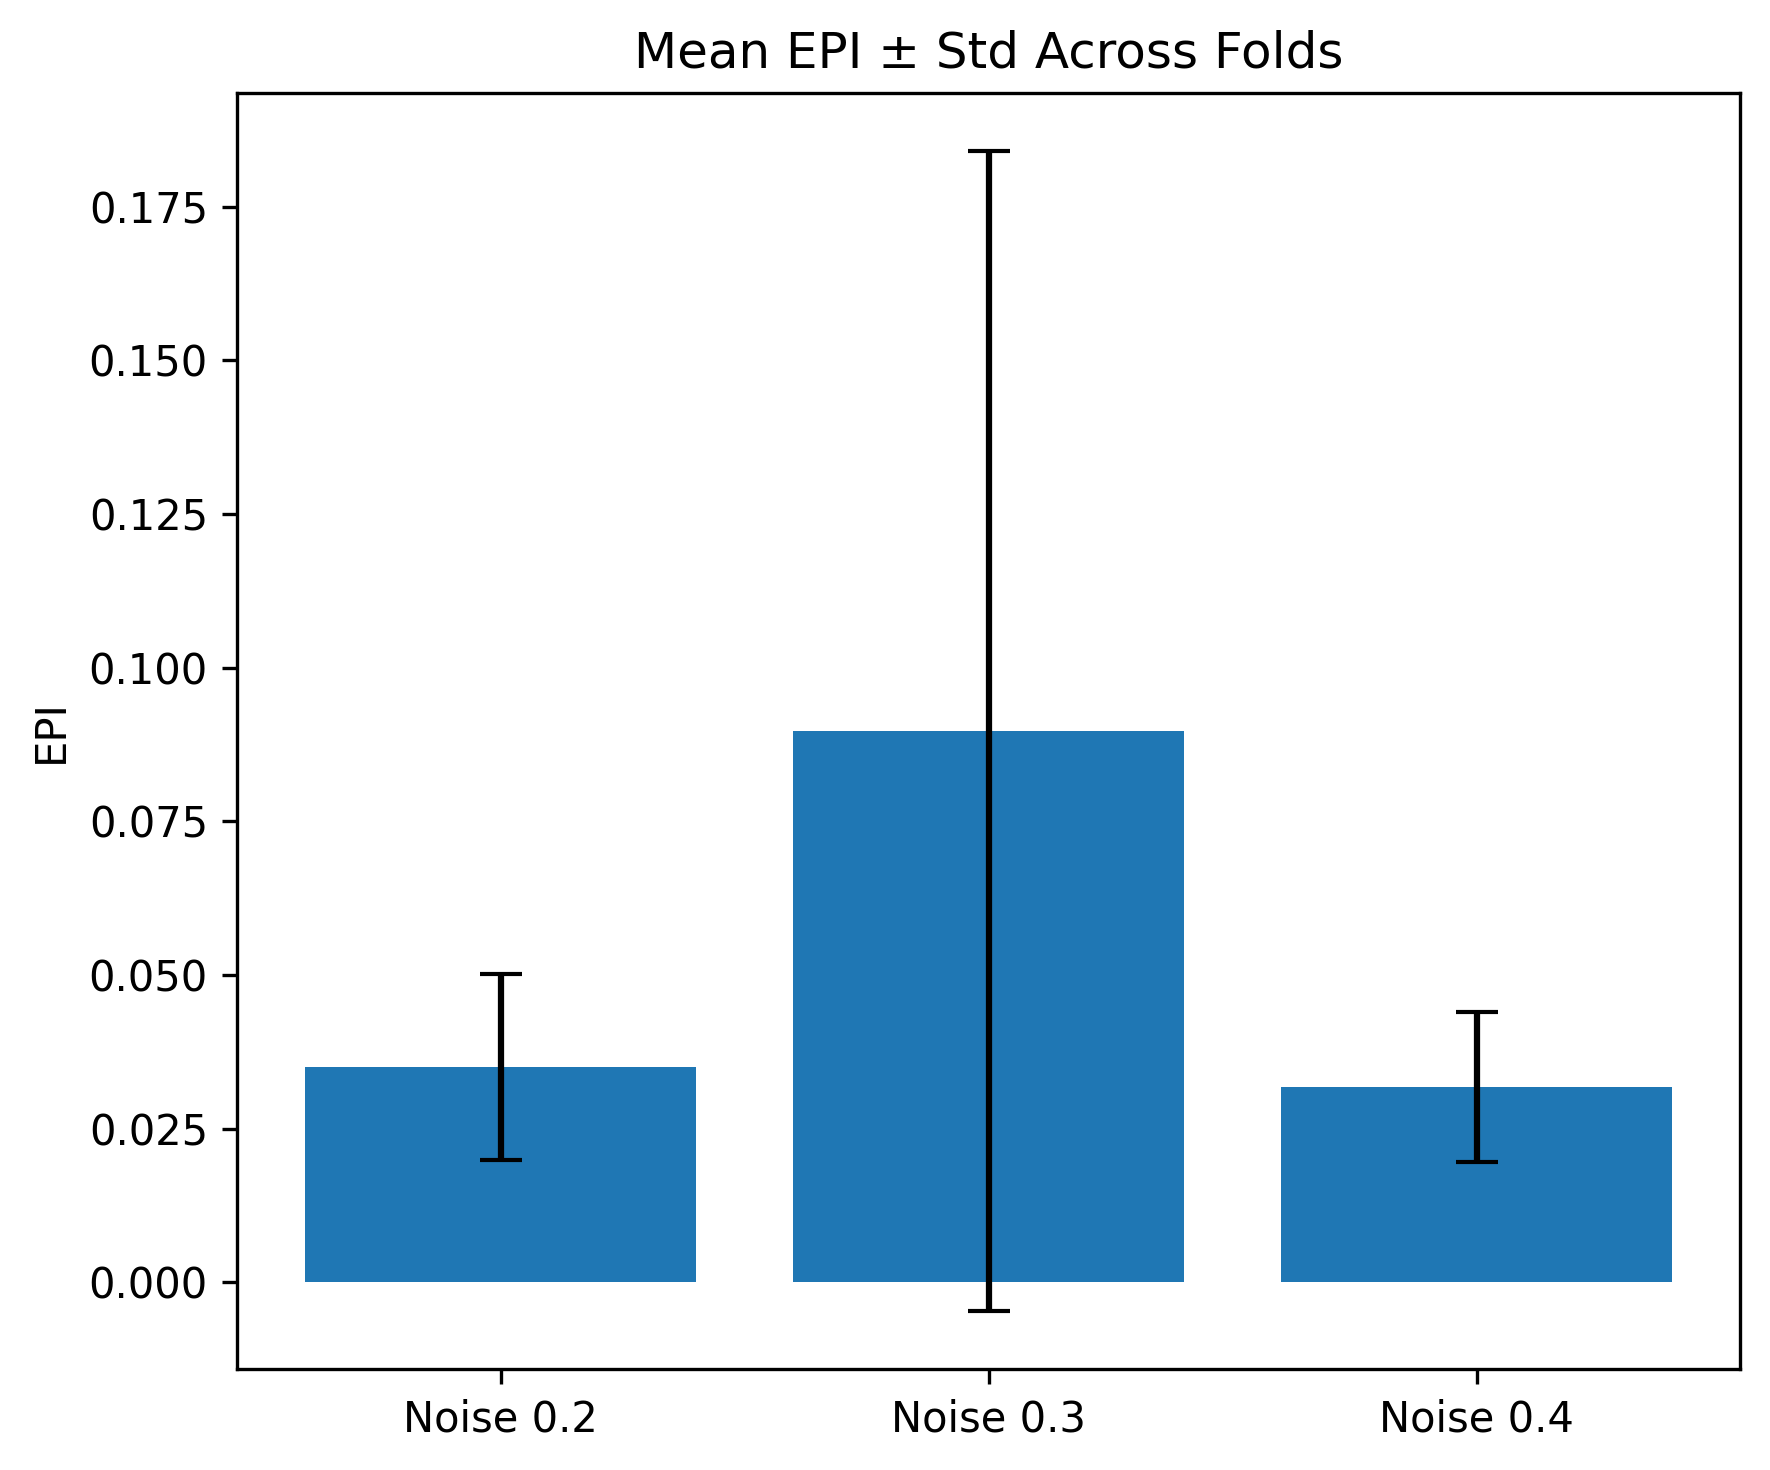

In [5]:
for metric in metrics:
    plt.figure(figsize=(6,5), dpi=300)

    means = []
    stds = []
    labels = []

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        means.append(np.mean(values))
        stds.append(np.std(values))
        labels.append(f"Noise {noise}")

    x = np.arange(len(labels))

    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels)
    plt.title(f"Mean {metric} ± Std Across Folds")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

In [9]:
# training vs validation loss

# make a list of the above values for plotting
folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]
train_losses = [0.0418, 0.0422, 0.0392, 0.0771, 0.0515]
val_losses = [0.0381, 0.0378, 0.0347, 0.0722, 0.0456]

# take average of traing and validation across folds
train_mean = np.mean(train_losses)
train_std = np.std(train_losses)
val_mean = np.mean(val_losses)
val_std = np.std(val_losses)

print(f"Train Loss: {train_mean:.4f} ± {train_std:.4f}")
print(f"Validation Loss: {val_mean:.4f} ± {val_std:.4f}")
# plot bar graph with error bars
# plt.figure(figsize=(6,5), dpi=300)
# x = np.arange(2)
# means = [train_mean, val_mean]
# stds = [train_std, val_std]
# labels = ["Train Loss", "Validation Loss"]  
# plt.bar(x, means, yerr=stds, capsize=5)
# plt.xticks(x, labels)
# plt.title("Mean Loss ± Std Across Folds")
# plt.ylabel("Loss")
# plt.tight_layout()
# plt.show()

Train Loss: 0.0504 ± 0.0140
Validation Loss: 0.0457 ± 0.0137
